# Aprendizado Não Supervisionado aplicado a Exoplanetas Confirmados (NASA)

**Disciplina:** Aprendizado de Máquina I — Projeto 02
**Tarefa:** Aprendizado não supervisionado
**Dataset:** [NASA's Confirmed Exoplanets](https://www.kaggle.com/datasets/jameskychoi/confirmed-exoplanet-latest-update-dataset) — NASA Exoplanet Archive

---

## Pergunta central

> *Que **tipos (arquétipos) de exoplanetas** existem no catálogo confirmado, como se distribuem no espaço de parâmetros físicos e orbitais, e quais planetas são **estatisticamente anômalos**?*

## Técnicas aplicadas (vistas em aula)

| Técnica | Métodos | Objetivo |
|---|---|---|
| **Redução de dim.** | PCA | Comprimir parâmetros físicos/orbitais correlacionados |
| **Agrupamento** | K-Means × DBSCAN | Descobrir tipos de planeta (super-Terras, gigantes gasosos, etc.) |
| **Detecção de anomalias** | Isolation Forest × LOF | Encontrar planetas exóticos / atípicos |
| **Extração de regras** | Apriori | Associar faixas de parâmetros, método de descoberta e tipo de planeta |
| **Regressão linear** | OLS sobre PCs | Relacionar componentes à temperatura de equilíbrio do planeta |

> **Observação metodológica:** todas as etapas centrais são *não supervisionadas*. A regressão linear é usada de forma **exploratória/descritiva**, não como tarefa preditiva supervisionada.


## 0. Setup e imports

In [24]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors, LocalOutlierFactor
from sklearn.ensemble import IsolationForest
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['figure.dpi'] = 110
print('Setup pronto. scikit-learn', __import__('sklearn').__version__)

Setup pronto. scikit-learn 1.9.0


## 1. Carregamento dos dados

O dataset utilizado e o **confirmed_exoplanents_2024_December.csv** com a nomenclatura do Kaggle.
As colunas sao mapeadas para o padrao do **NASA Exoplanet Archive**:

| Coluna original (CSV) | Coluna padronizada | Significado |
|---|---|---|
| `orbital_period_days` | `pl_orbper` | Periodo orbital (dias) |
| `planet_radius_earth_radius` | `pl_rade` | Raio do planeta (raios da Terra) |
| `planet_mass_earth_mass` | `pl_bmasse` | Massa do planeta (massas da Terra) |
| `orbit_semi_major_axis_au` | `pl_orbsmax` | Semieixo maior (UA) |
| `eccentricity` | `pl_orbeccen` | Excentricidade orbital |
| `equilibrium_temperature_k` | `pl_eqt` | Temperatura de equilibrio (K) |
| `insolation_flux_earth_flux` | `pl_insol` | Fluxo de insolacao (relativo a Terra) |
| `stellar_effective_temp_k` | `st_teff` | Temperatura efetiva da estrela (K) |
| `stellar_radius_solar_radius` | `st_rad` | Raio estelar (raios solares) |
| `stellar_mass_solar_mass` | `st_mass` | Massa estelar (massas solares) |
| `stellar_metallicity_dex` | `st_met` | Metalicidade estelar (dex) |
| `distance_pc` | `sy_dist` | Distancia do sistema (parsecs) |
| `discovery_method` | `discoverymethod` | Metodo de descoberta (categorica) |


In [25]:
from pathlib import Path

CSV_PATH = Path('confirmed_exoplanents_2024_December.csv')

# Mapeamento: nomes do CSV → nomenclatura NASA Exoplanet Archive
COL_MAP = {
    'planet_name':                 'pl_name',
    'orbital_period_days':         'pl_orbper',
    'planet_radius_earth_radius':  'pl_rade',
    'planet_mass_earth_mass':      'pl_bmasse',
    'orbit_semi_major_axis_au':    'pl_orbsmax',
    'eccentricity':                'pl_orbeccen',
    'equilibrium_temperature_k':   'pl_eqt',
    'insolation_flux_earth_flux':  'pl_insol',
    'stellar_effective_temp_k':    'st_teff',
    'stellar_radius_solar_radius': 'st_rad',
    'stellar_mass_solar_mass':     'st_mass',
    'stellar_metallicity_dex':     'st_met',
    'distance_pc':                 'sy_dist',
    'discovery_method':            'discoverymethod',
}

NUM_COLS = ['pl_orbper','pl_rade','pl_bmasse','pl_orbsmax','pl_orbeccen',
            'pl_eqt','pl_insol','st_teff','st_rad','st_mass','st_met','sy_dist']
CAT_COL  = 'discoverymethod'

df_raw = pd.read_csv(CSV_PATH, na_values=['NULL', ''])
df_raw = df_raw.rename(columns=COL_MAP)
keep = [c for c in NUM_COLS + [CAT_COL, 'pl_name'] if c in df_raw.columns]
df = df_raw[keep].copy()
print(f'Dados carregados: {df.shape[0]} planetas, {df.shape[1]} colunas')
df.head()

Dados carregados: 5788 planetas, 14 colunas


,pl_orbper,pl_rade,pl_bmasse,pl_orbsmax,pl_orbeccen,pl_eqt,pl_insol,st_teff,st_rad,st_mass,st_met,sy_dist,discoverymethod,pl_name
0,17.871900,1.660,3.41,0.08900,0.110,NaN,1.30,3342.0,0.31,0.29,-0.09,4.30592,Radial Velocity,Wolf 1061 c
1,217.210000,2.690,7.70,0.47000,0.550,NaN,0.06,3342.0,0.31,0.29,-0.09,4.30592,Radial Velocity,Wolf 1061 d
2,15.564000,1.080,1.26,0.06720,NaN,250.0,0.65,3158.0,0.18,0.17,0.07,9.58341,Radial Velocity,Wolf 1069 b
3,0.573474,1.240,2.53,0.01000,0.000,996.0,233.90,3542.0,0.41,0.41,-0.17,28.53210,Transit,Wolf 327 b
4,6.001270,2.043,6.27,0.05712,0.409,789.0,64.70,4716.0,0.69,0.69,-0.47,44.52600,Transit,Wolf 503 b


## 2. Análise Exploratória (EDA)

Entendemos distribuições, escala e correlações antes de modelar — o que justifica normalização e a necessidade de PCA.

In [26]:
FEATURES = [c for c in NUM_COLS if c in df.columns]
data = df[FEATURES].apply(pd.to_numeric, errors='coerce')

print('Valores ausentes por coluna:')
print(data.isna().sum())

# muitos parâmetros físicos têm forte assimetria → log ajuda na visualização e no PCA
LOG_COLS = [c for c in ['pl_orbper','pl_bmasse','pl_rade','pl_orbsmax','pl_insol','sy_dist'] if c in data.columns]
for c in LOG_COLS:
    data[c] = np.log10(data[c].clip(lower=1e-3))

data = data.dropna()
df = df.loc[data.index].reset_index(drop=True)
data = data.reset_index(drop=True)
print('\nShape após limpeza:', data.shape)
data.describe().T[['mean','std','min','max']]

Valores ausentes por coluna:
pl_orbper       281
pl_rade          21
pl_bmasse        30
pl_orbsmax      282
pl_orbeccen     821
pl_eqt         1485
pl_insol       1748
st_teff         244
st_rad          266
st_mass           7
st_met          479
sy_dist          25
dtype: int64

Shape após limpeza: (3686, 12)


,mean,std,min,max
pl_orbper,1.001628,0.555843,-0.552339,3.568202
pl_rade,0.452507,0.355583,-0.508638,1.397940
pl_bmasse,1.020721,0.807293,-1.427128,3.937224
pl_orbsmax,-1.054519,0.377175,-2.221849,0.698970
pl_orbeccen,0.033574,0.096949,0.000000,0.924000
pl_eqt,907.539067,446.646046,96.000000,4050.000000
pl_insol,1.959004,0.851695,-1.698970,4.652246
st_teff,5451.672309,760.314595,2566.000000,10170.000000
st_rad,1.025364,0.415855,0.120000,6.300000
st_mass,0.951017,0.253927,0.090000,2.780000


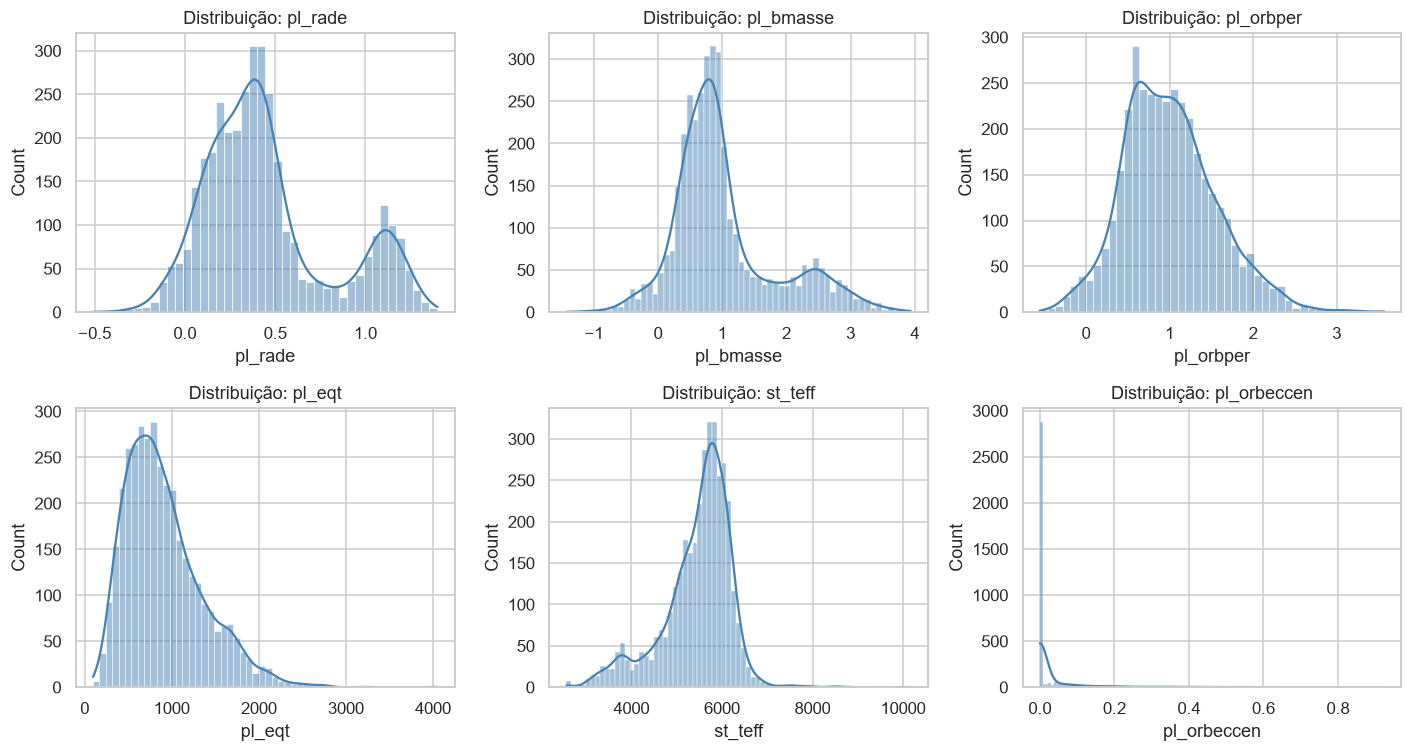

Obs.: variáveis em log10 onde indicado (raio, massa, período, etc.).


In [27]:
cols_plot=[c for c in ['pl_rade','pl_bmasse','pl_orbper','pl_eqt','st_teff','pl_orbeccen'] if c in data.columns]
fig,axes=plt.subplots(2,3,figsize=(13,7))
for ax,col in zip(axes.ravel(),cols_plot):
    sns.histplot(data[col],kde=True,ax=ax,color='steelblue')
    ax.set_title(f'Distribuição: {col}')
plt.tight_layout(); plt.show()
print('Obs.: variáveis em log10 onde indicado (raio, massa, período, etc.).')

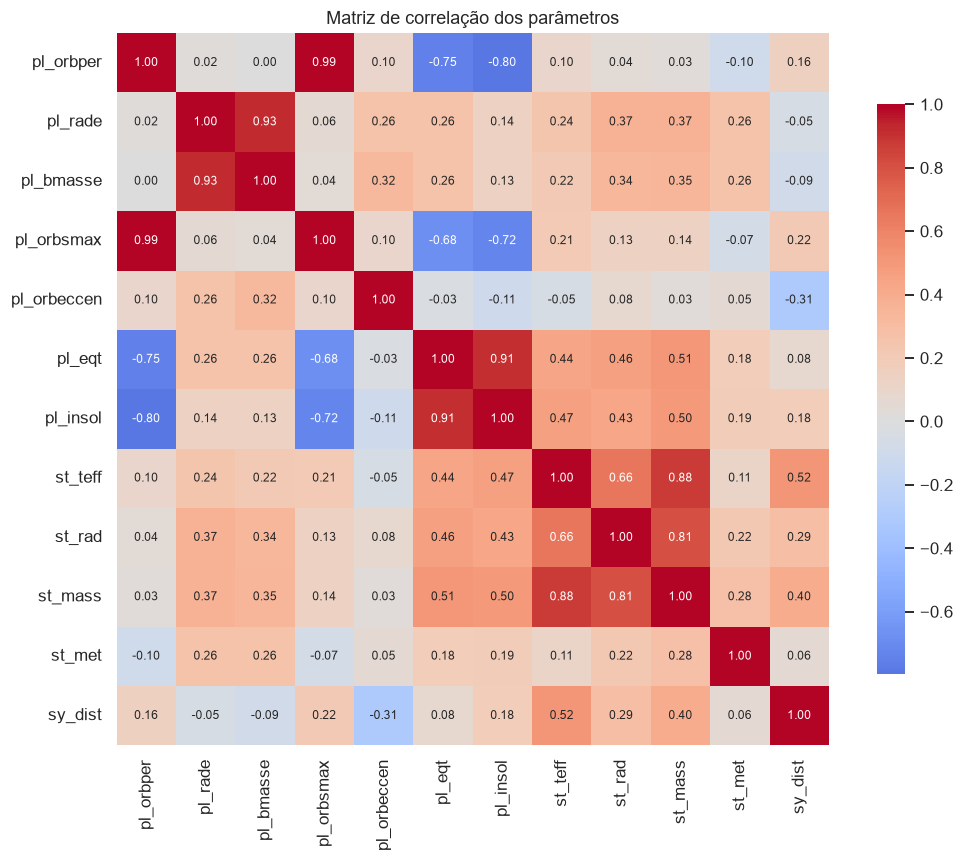

Pares como raio/massa e período/semieixo são fortemente correlacionados →
há redundância, o que JUSTIFICA a redução de dimensionalidade via PCA.


In [28]:
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(),annot=True,fmt='.2f',cmap='coolwarm',center=0,
            square=True,cbar_kws={'shrink':.8},annot_kws={'size':8})
plt.title('Matriz de correlação dos parâmetros')
plt.tight_layout(); plt.show()
print('Pares como raio/massa e período/semieixo são fortemente correlacionados →')
print('há redundância, o que JUSTIFICA a redução de dimensionalidade via PCA.')

## 3. Pré-processamento

**Normalização (StandardScaler):** indispensável porque os parâmetros têm escalas e unidades muito diferentes (Kelvin, dias, massas terrestres, parsecs). PCA e métodos baseados em distância (K-Means, DBSCAN, LOF) são sensíveis à escala.

In [29]:
scaler=StandardScaler()
X=pd.DataFrame(scaler.fit_transform(data.values),columns=data.columns)
print('Média ~0 e desvio ~1 após padronização:')
print(X.describe().T[['mean','std']].round(3).head())

Média ~0 e desvio ~1 após padronização:
             mean  std
pl_orbper     0.0  1.0
pl_rade       0.0  1.0
pl_bmasse     0.0  1.0
pl_orbsmax    0.0  1.0
pl_orbeccen  -0.0  1.0


## 4. PCA — Redução de dimensionalidade

**Justificativa:** parâmetros físicos correlacionados (raio/massa, período/semieixo, insolação/temperatura) podem ser comprimidos em poucos eixos não correlacionados, facilitando visualização e reduzindo ruído.

**Ajuste de parâmetro:** nº de componentes pela **variância explicada acumulada** (alvo ≥ 85%).

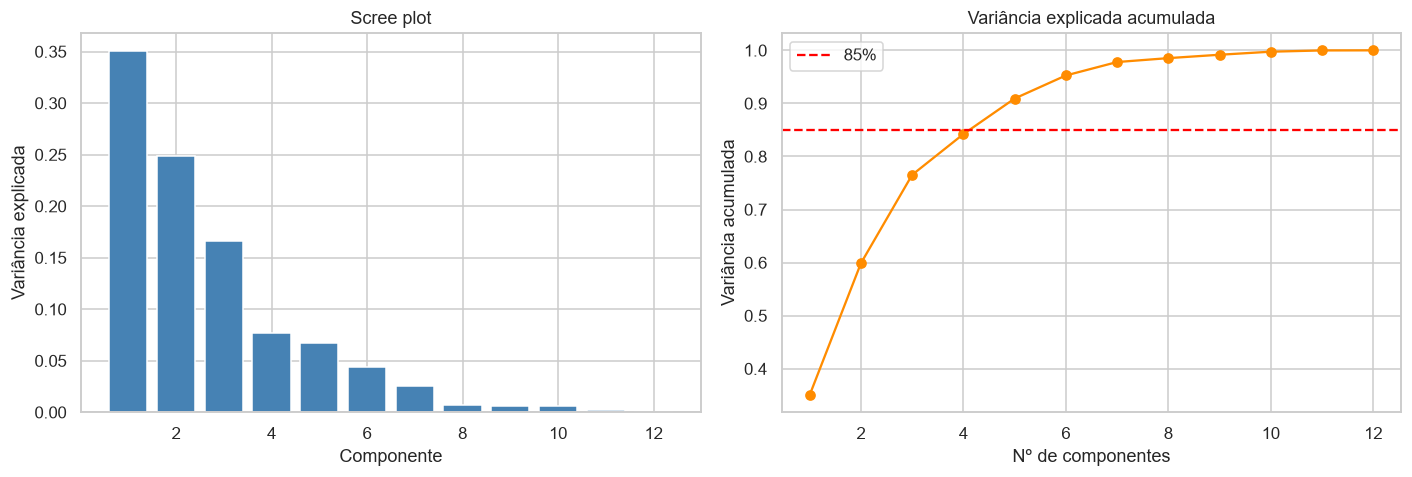

Componentes para >=85% da variância: 5


In [30]:
pca_full=PCA(random_state=RANDOM_STATE).fit(X)
cumvar=np.cumsum(pca_full.explained_variance_ratio_)
fig,(a1,a2)=plt.subplots(1,2,figsize=(13,4.5))
a1.bar(range(1,len(pca_full.explained_variance_ratio_)+1),pca_full.explained_variance_ratio_,color='steelblue')
a1.set_xlabel('Componente'); a1.set_ylabel('Variância explicada'); a1.set_title('Scree plot')
a2.plot(range(1,len(cumvar)+1),cumvar,'o-',color='darkorange')
a2.axhline(0.85,ls='--',color='red',label='85%')
a2.set_xlabel('Nº de componentes'); a2.set_ylabel('Variância acumulada')
a2.set_title('Variância explicada acumulada'); a2.legend()
plt.tight_layout(); plt.show()
n_comp=int(np.argmax(cumvar>=0.85)+1)
print(f'Componentes para >=85% da variância: {n_comp}')

In [31]:
pca=PCA(n_components=n_comp,random_state=RANDOM_STATE)
X_pca=pd.DataFrame(pca.fit_transform(X),columns=[f'PC{i+1}' for i in range(n_comp)])
loadings=pd.DataFrame(pca.components_.T,index=data.columns,
                      columns=[f'PC{i+1}' for i in range(n_comp)])
print('Loadings (3 primeiros PCs):')
loadings.iloc[:,:min(3,n_comp)].round(2)

Loadings (3 primeiros PCs):


,PC1,PC2,PC3
pl_orbper,-0.24,0.50,-0.05
pl_rade,0.24,0.22,0.47
pl_bmasse,0.23,0.21,0.50
pl_orbsmax,-0.19,0.52,-0.08
pl_orbeccen,0.01,0.11,0.43
pl_eqt,0.43,-0.23,-0.00
pl_insol,0.42,-0.26,-0.11
st_teff,0.34,0.28,-0.27
st_rad,0.35,0.26,-0.08
st_mass,0.39,0.27,-0.14


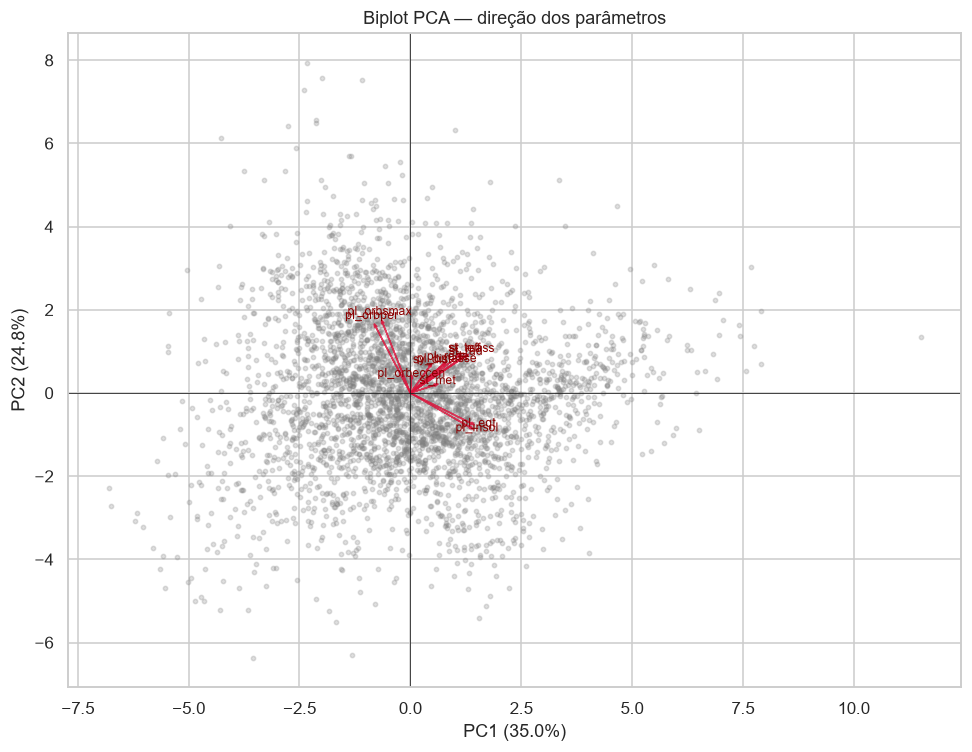

In [32]:
fig,ax=plt.subplots(figsize=(9,7))
ax.scatter(X_pca['PC1'],X_pca['PC2'],s=8,alpha=0.25,color='gray')
scale=3.2
for i,feat in enumerate(data.columns):
    ax.arrow(0,0,pca.components_[0,i]*scale,pca.components_[1,i]*scale,
             color='crimson',alpha=0.8,head_width=0.06)
    ax.text(pca.components_[0,i]*scale*1.12,pca.components_[1,i]*scale*1.12,
            feat,color='darkred',fontsize=8,ha='center')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('Biplot PCA — direção dos parâmetros')
ax.axhline(0,color='k',lw=.5); ax.axvline(0,color='k',lw=.5)
plt.tight_layout(); plt.show()

## 5. Agrupamento (Clustering)

Dois algoritmos complementares no espaço do PCA:

- **K-Means** — particional, exige `k`, rápido e interpretável.
- **DBSCAN** — densidade, descobre o nº de grupos e isola ruído (planetas raros).

### 5.1 K-Means — escolha de `k` (Elbow + Silhouette)

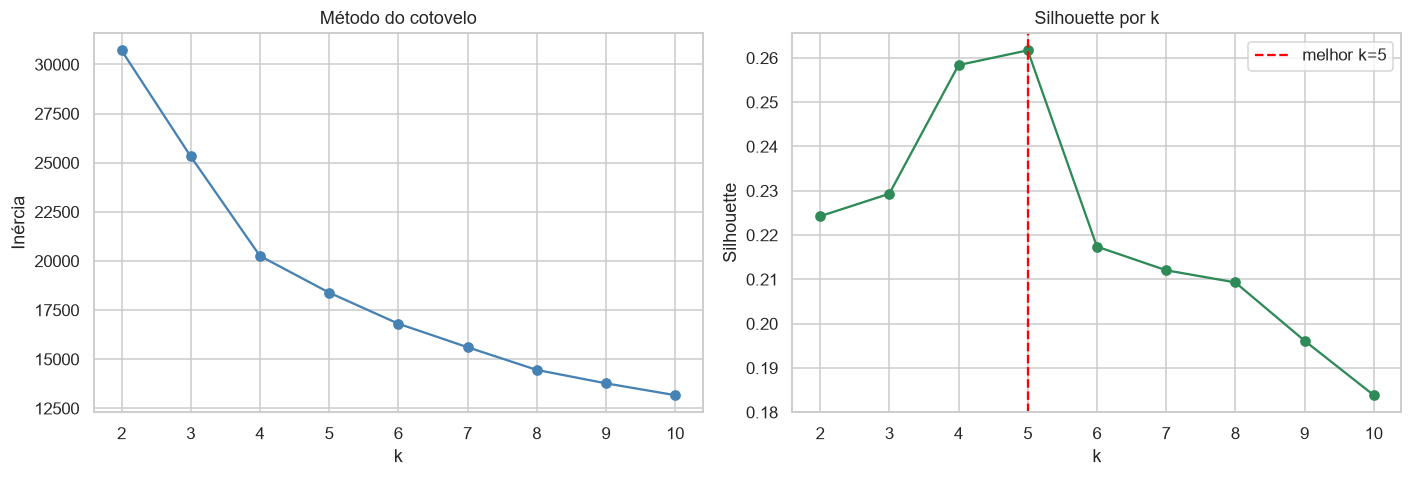

k escolhido pela silhueta: 5


In [33]:
ks=range(2,11); inertias=[]; sils=[]
for k in ks:
    km=KMeans(n_clusters=k,random_state=RANDOM_STATE,n_init=10).fit(X_pca)
    inertias.append(km.inertia_); sils.append(silhouette_score(X_pca,km.labels_))
fig,(a1,a2)=plt.subplots(1,2,figsize=(13,4.5))
a1.plot(list(ks),inertias,'o-',color='steelblue'); a1.set_xlabel('k'); a1.set_ylabel('Inércia'); a1.set_title('Método do cotovelo')
a2.plot(list(ks),sils,'o-',color='seagreen'); a2.set_xlabel('k'); a2.set_ylabel('Silhouette'); a2.set_title('Silhouette por k')
best_k=list(ks)[int(np.argmax(sils))]
a2.axvline(best_k,ls='--',color='red',label=f'melhor k={best_k}'); a2.legend()
plt.tight_layout(); plt.show()
print(f'k escolhido pela silhueta: {best_k}')

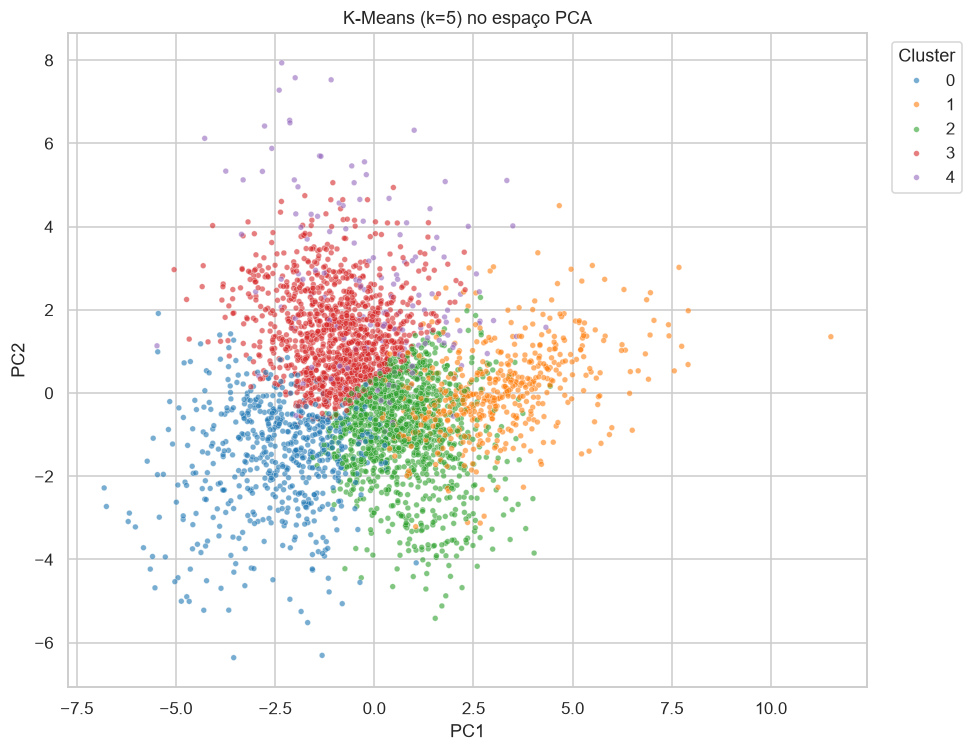

In [34]:
kmeans=KMeans(n_clusters=best_k,random_state=RANDOM_STATE,n_init=10)
labels_km=kmeans.fit_predict(X_pca); df['cluster_km']=labels_km
plt.figure(figsize=(9,7))
sns.scatterplot(x=X_pca['PC1'],y=X_pca['PC2'],hue=labels_km,palette='tab10',s=14,alpha=0.6,legend='full')
plt.title(f'K-Means (k={best_k}) no espaço PCA'); plt.xlabel('PC1'); plt.ylabel('PC2')
plt.legend(title='Cluster',bbox_to_anchor=(1.02,1),loc='upper left')
plt.tight_layout(); plt.show()

In [35]:
# Perfil médio dos clusters (nas variáveis originais, revertendo log onde aplicável)
prof=data.copy()
for c in LOG_COLS:
    prof[c]=10**prof[c]
prof['cluster']=labels_km
cluster_means=prof.groupby('cluster').mean().round(2)
print('Perfil médio de cada cluster (unidades originais):')
cluster_means

Perfil médio de cada cluster (unidades originais):


,pl_orbper,pl_rade,pl_bmasse,pl_orbsmax,pl_orbeccen,pl_eqt,pl_insol,st_teff,st_rad,st_mass,st_met,sy_dist
cluster,,,,,,,,,,,,
0,11.75,2.67,35.78,0.08,0.05,592.94,46.86,4155.48,0.57,0.59,-0.07,208.85
1,4.39,13.44,503.22,0.05,0.05,1533.28,1446.36,5918.61,1.44,1.20,0.11,446.44
2,5.95,1.91,6.23,0.06,0.01,1140.46,605.41,5681.63,1.06,1.00,0.04,796.93
3,51.11,3.00,24.76,0.24,0.01,581.42,40.45,5629.16,1.01,0.96,-0.00,865.61
4,199.65,7.98,590.22,0.47,0.36,689.82,96.64,5650.79,1.26,1.06,0.08,280.42


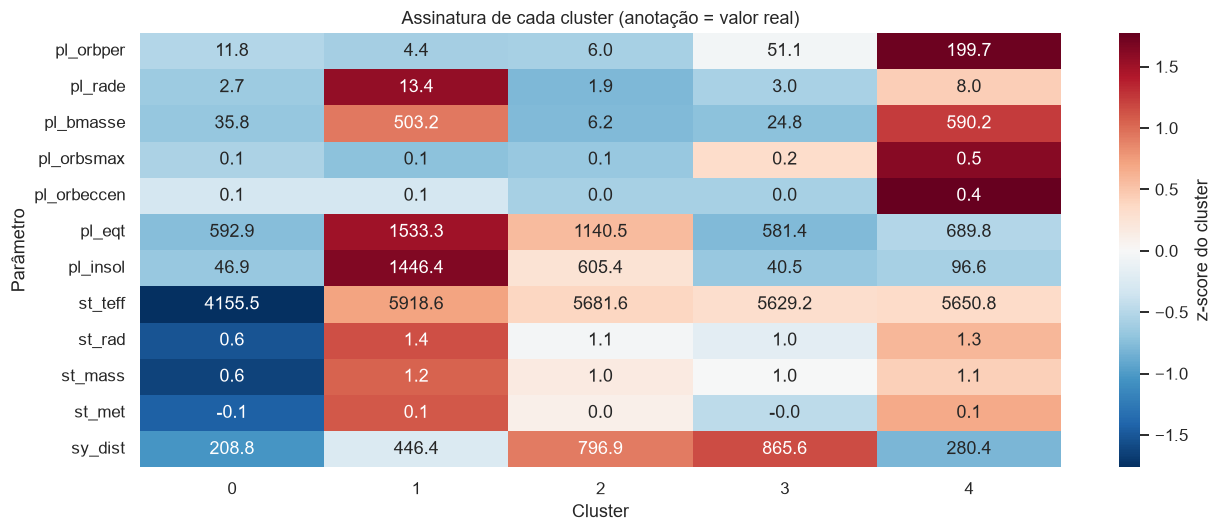

Leitura: vermelho = acima da média dos clusters; azul = abaixo.


In [36]:
prof_z=(cluster_means-cluster_means.mean())/cluster_means.std()
plt.figure(figsize=(12,5))
sns.heatmap(prof_z.T,annot=cluster_means.T,fmt='.1f',cmap='RdBu_r',center=0,
            cbar_kws={'label':'z-score do cluster'})
plt.title('Assinatura de cada cluster (anotação = valor real)')
plt.xlabel('Cluster'); plt.ylabel('Parâmetro')
plt.tight_layout(); plt.show()
print('Leitura: vermelho = acima da média dos clusters; azul = abaixo.')

### 5.2 DBSCAN — ajuste de `eps` via k-distance plot

Em alta dimensão as distâncias inflam (maldição da dimensionalidade), então aplicamos o DBSCAN sobre os 2 primeiros componentes, onde a densidade é mais significativa e a visualização é direta.

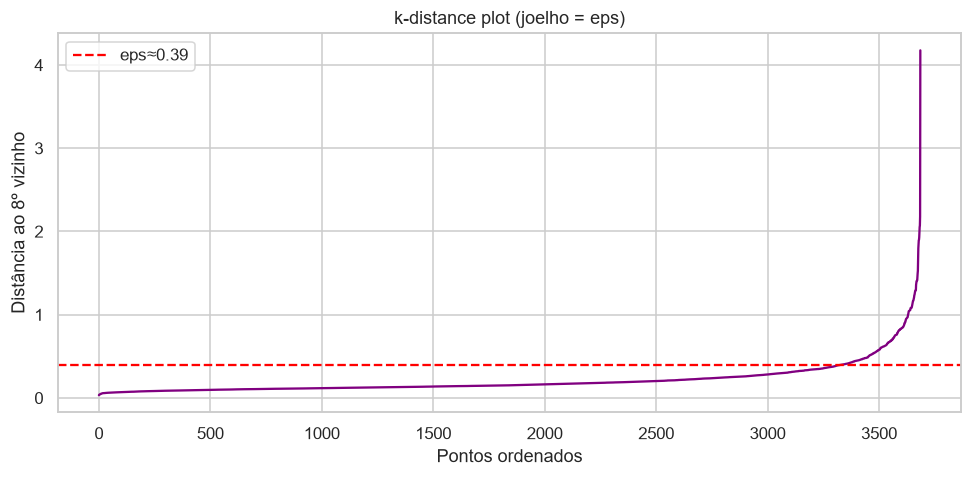

eps estimado: 0.392 | min_samples: 8


In [37]:
X_db=X_pca[['PC1','PC2']].values
min_samples=8
nn=NearestNeighbors(n_neighbors=min_samples).fit(X_db)
dists,_=nn.kneighbors(X_db)
kdist=np.sort(dists[:,-1])
eps_guess=float(np.percentile(kdist,90))   # percentil 90: robusto contra excesso de ruído
plt.figure(figsize=(9,4.5))
plt.plot(kdist,color='purple')
plt.axhline(eps_guess,ls='--',color='red',label=f'eps≈{eps_guess:.2f}')
plt.xlabel('Pontos ordenados'); plt.ylabel(f'Distância ao {min_samples}º vizinho')
plt.title('k-distance plot (joelho = eps)'); plt.legend()
plt.tight_layout(); plt.show()
print(f'eps estimado: {eps_guess:.3f} | min_samples: {min_samples}')

DBSCAN: 3 clusters e 236 pontos de ruído (6.4%)


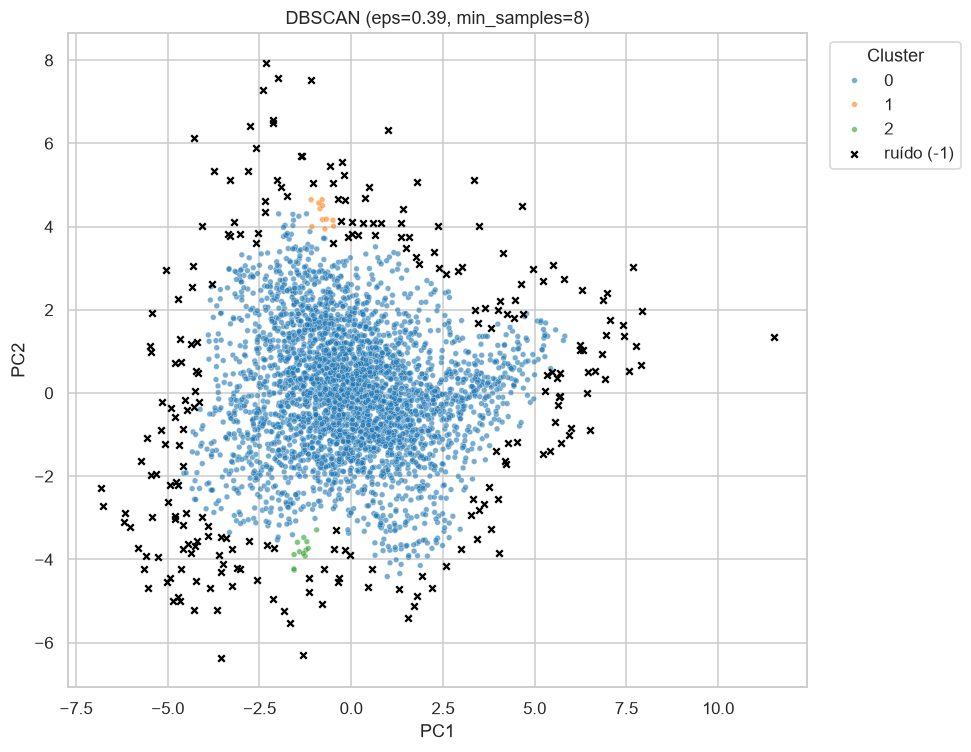

In [38]:
dbscan=DBSCAN(eps=eps_guess,min_samples=min_samples)
labels_db=dbscan.fit_predict(X_db); df['cluster_db']=labels_db
n_clusters_db=len(set(labels_db))-(1 if -1 in labels_db else 0)
n_noise=int((labels_db==-1).sum())
print(f'DBSCAN: {n_clusters_db} clusters e {n_noise} pontos de ruído ({100*n_noise/len(labels_db):.1f}%)')
plt.figure(figsize=(9,7))
mask=labels_db==-1
sns.scatterplot(x=X_pca['PC1'][~mask],y=X_pca['PC2'][~mask],hue=labels_db[~mask],
                palette='tab10',s=14,alpha=0.6,legend='full')
plt.scatter(X_pca['PC1'][mask],X_pca['PC2'][mask],c='black',s=18,marker='x',label='ruído (-1)')
plt.title(f'DBSCAN (eps={eps_guess:.2f}, min_samples={min_samples})')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.legend(title='Cluster',bbox_to_anchor=(1.02,1),loc='upper left')
plt.tight_layout(); plt.show()

### 5.3 Comparação K-Means × DBSCAN

 Método  Nº clusters  Silhouette (↑)  Dunn (↑)  % ruído
K-Means            5           0.262     0.012    0.000
 DBSCAN            3           0.140     0.012    6.403


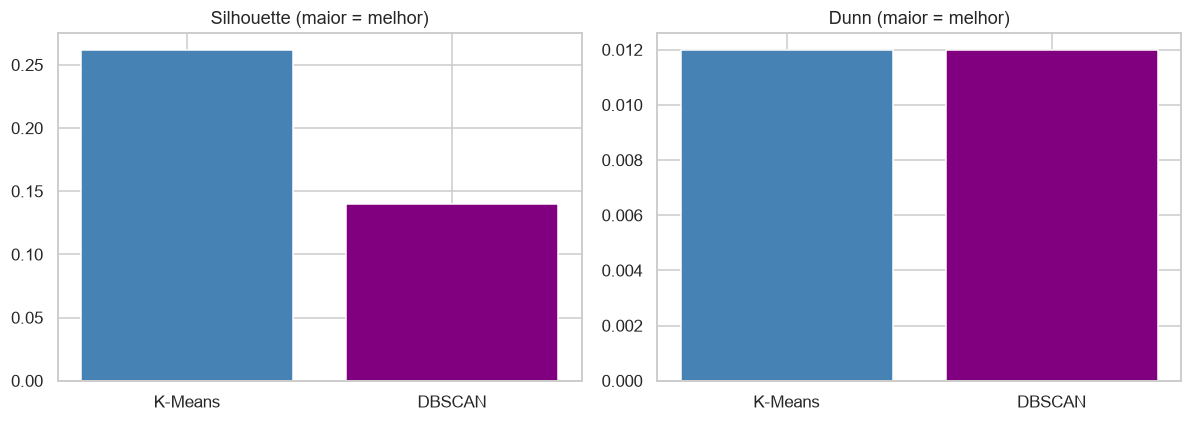

In [39]:
from sklearn.metrics import pairwise_distances

def dunn_index(Xe, lb):
    Xe, lb = np.asarray(Xe), np.asarray(lb)
    m = lb != -1
    Xe, lb = Xe[m], lb[m]
    cls = [Xe[lb == c] for c in sorted(set(lb))]
    if len(cls) < 2:
        return np.nan
    inter = min(pairwise_distances(cls[i], cls[j]).min()
                for i in range(len(cls)) for j in range(i+1, len(cls)))
    intra = max(pairwise_distances(c).max() for c in cls if len(c) > 1)
    return inter / intra

def safe_sil(Xe, lb):
    m = lb != -1
    if len(set(lb[m])) < 2:
        return np.nan
    return silhouette_score(Xe[m], lb[m])

sil_km = safe_sil(X_pca.values, labels_km)
sil_db = safe_sil(X_db, labels_db)
dunn_km = dunn_index(X_pca.values, labels_km)
dunn_db = dunn_index(X_db, labels_db)

comp = pd.DataFrame({
    'Método': ['K-Means', 'DBSCAN'],
    'Nº clusters': [best_k, n_clusters_db],
    'Silhouette (↑)': [sil_km, sil_db],
    'Dunn (↑)': [dunn_km, dunn_db],
    '% ruído': [0.0, 100*n_noise/len(labels_db)],
}).round(3)
print(comp.to_string(index=False))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
a1.bar(comp['Método'], comp['Silhouette (↑)'], color=['steelblue','purple'])
a1.set_title('Silhouette (maior = melhor)')
a2.bar(comp['Método'], comp['Dunn (↑)'], color=['steelblue','purple'])
a2.set_title('Dunn (maior = melhor)')
plt.tight_layout(); plt.show()

## 6. Detecção de anomalias

Procuramos **planetas estatisticamente atípicos** — ultra-densos, "inchados" (baixa densidade), órbitas extremas. Comparamos:

- **Isolation Forest** — isola pontos via partições aleatórias; eficiente em alta dimensão (`contamination`).
- **Local Outlier Factor (LOF)** — densidade local relativa aos vizinhos (`n_neighbors`).

In [40]:
CONTAM=0.01
iso=IsolationForest(contamination=CONTAM,random_state=RANDOM_STATE)
out_iso=iso.fit_predict(X); score_iso=-iso.score_samples(X)
lof=LocalOutlierFactor(n_neighbors=20,contamination=CONTAM)
out_lof=lof.fit_predict(X); score_lof=-lof.negative_outlier_factor_
df['anom_iso']=out_iso==-1; df['anom_lof']=out_lof==-1; df['score_iso']=score_iso
print(f'Isolation Forest: {df.anom_iso.sum()} anomalias')
print(f'LOF:              {df.anom_lof.sum()} anomalias')
print(f'Concordância:     {(df.anom_iso & df.anom_lof).sum()}')

Isolation Forest: 37 anomalias
LOF:              37 anomalias
Concordância:     2


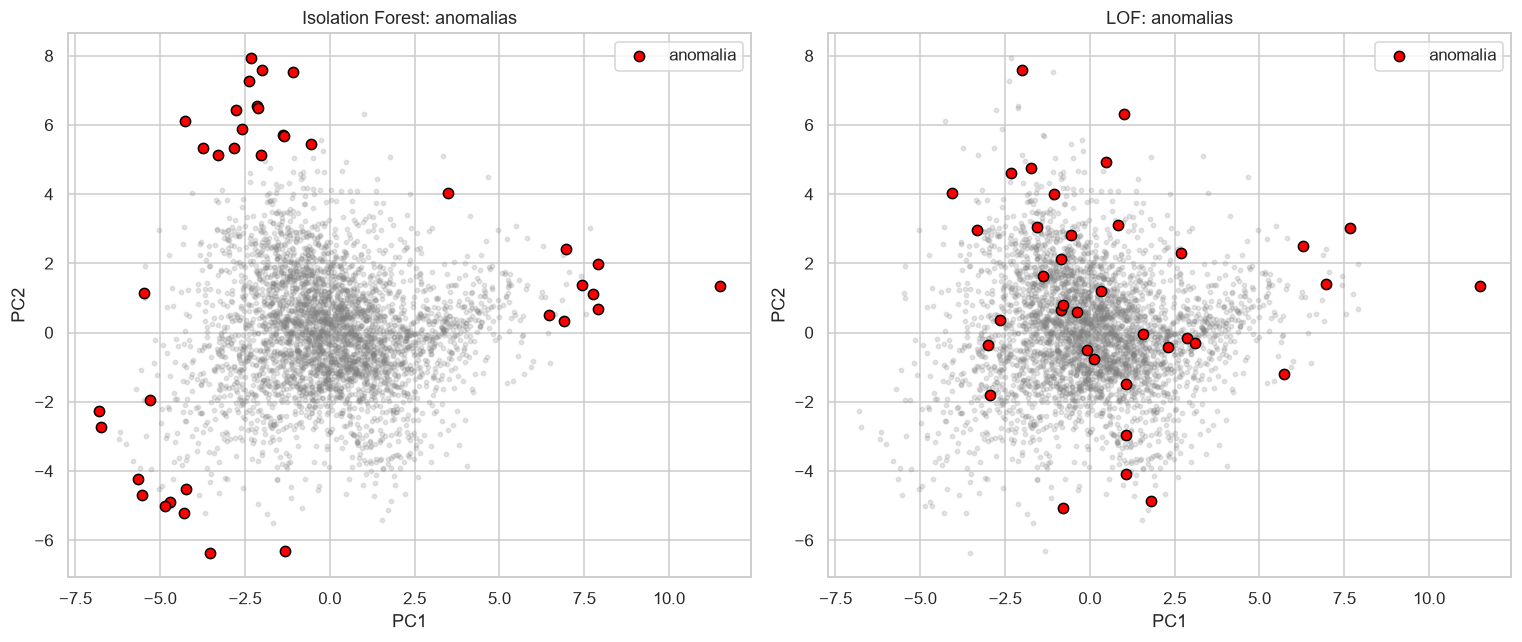

In [41]:
fig,axes=plt.subplots(1,2,figsize=(14,6))
for ax,col,title in [(axes[0],'anom_iso','Isolation Forest'),(axes[1],'anom_lof','LOF')]:
    ax.scatter(X_pca['PC1'],X_pca['PC2'],s=8,alpha=0.2,color='gray')
    m=df[col].values
    ax.scatter(X_pca['PC1'][m],X_pca['PC2'][m],s=45,color='red',edgecolor='black',label='anomalia')
    ax.set_title(f'{title}: anomalias'); ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.legend()
plt.tight_layout(); plt.show()

In [42]:
show=[c for c in ['pl_name','discoverymethod','pl_rade','pl_bmasse','pl_orbper','pl_eqt','sy_dist','score_iso'] if c in df.columns]
print('Top planetas mais anômalos (Isolation Forest):')
df.sort_values('score_iso',ascending=False).head(12)[show].round(3)

Top planetas mais anômalos (Isolation Forest):


,pl_name,discoverymethod,pl_rade,pl_bmasse,pl_orbper,pl_eqt,sy_dist,score_iso
3106,TOI-969 c,Radial Velocity,12.400,3591.461,1700.000,96.0,77.255,0.694
2913,HD 80869 b,Radial Velocity,12.800,1609.801,1752.921,203.0,85.395,0.678
2028,HD 115954 b,Radial Velocity,12.600,2685.650,3700.000,145.0,87.644,0.672
1396,EPIC 248847494 b,Transit,12.442,4131.790,3650.000,183.0,551.886,0.667
2090,Kepler-1704 b,Transit,11.949,1322.166,988.881,254.0,835.455,0.663
1207,Barnard b,Radial Velocity,0.764,0.370,3.153,400.0,1.827,0.663
150,KELT-9 b,Transit,21.196,915.350,1.481,4050.0,204.455,0.659
2156,TIC 139270665 c,Radial Velocity,12.900,1554.181,1010.000,200.0,189.875,0.652
2816,TOI-4010 e,Radial Velocity,13.300,692.000,762.000,174.0,177.504,0.643
101,Kepler-42 d,Transit,0.570,0.130,1.865,450.0,40.060,0.639


## 7. Extração de regras de associação (Apriori)

Buscamos co-ocorrências entre faixas de parâmetros, método de descoberta e tipo de planeta. Discretizamos as variáveis contínuas em faixas (baixo/médio/alto) por quantis.

In [43]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

def to_items(df_in, data_in):
    def band(s,name):
        q=s.quantile([.33,.66])
        bins=[-np.inf,q.iloc[0],q.iloc[1],np.inf]
        all_labels=[f'{name}=baixo',f'{name}=médio',f'{name}=alto']
        unique_bins=list(dict.fromkeys(bins))
        labels=all_labels[:len(unique_bins)-1]
        return pd.cut(s,unique_bins,labels=labels).astype(str)
    cols={}
    for c,nm in [('pl_rade','RAIO'),('pl_bmasse','MASSA'),('pl_orbper','PERIODO'),
                 ('pl_eqt','TEMP'),('st_teff','STAR_T'),('pl_orbeccen','ECC')]:
        if c in data_in.columns: cols[nm]=band(data_in[c],nm)
    base=pd.DataFrame(cols)
    if 'discoverymethod' in df_in.columns:
        base['METODO']='METODO='+df_in['discoverymethod'].astype(str)
    return base.apply(lambda r:[v for v in r.values if v!='nan'],axis=1).tolist()

transactions=to_items(df,data)
te=TransactionEncoder(); te_ary=te.fit_transform(transactions)
basket=pd.DataFrame(te_ary,columns=te.columns_)
print('Matriz transacional:',basket.shape)
freq=apriori(basket,min_support=0.05,use_colnames=True)
rules=association_rules(freq,metric='confidence',min_threshold=0.6).sort_values('lift',ascending=False)
rules_show=rules[rules['lift']>1.2].copy()
rules_show['antecedents']=rules_show['antecedents'].apply(lambda s:', '.join(sorted(s)))
rules_show['consequents']=rules_show['consequents'].apply(lambda s:', '.join(sorted(s)))
print(f'{len(rules)} regras; {len(rules_show)} com lift>1.2\n')
rules_show[['antecedents','consequents','support','confidence','lift']].head(15).round(3)

Matriz transacional: (3686, 21)
1929 regras; 1268 com lift>1.2



,antecedents,consequents,support,confidence,lift
1659,"MASSA=alto, PERIODO=baixo, STAR_T=alto","RAIO=alto, TEMP=alto",0.060,0.982,6.476
1924,"MASSA=alto, METODO=Transit, PERIODO=baixo, STA...","RAIO=alto, TEMP=alto",0.059,0.982,6.475
1928,"MASSA=alto, PERIODO=baixo, STAR_T=alto","METODO=Transit, RAIO=alto, TEMP=alto",0.059,0.969,6.446
1657,"PERIODO=baixo, RAIO=alto, STAR_T=alto","MASSA=alto, TEMP=alto",0.060,0.982,6.407
1921,"METODO=Transit, PERIODO=baixo, RAIO=alto, STAR...","MASSA=alto, TEMP=alto",0.059,0.982,6.406
1926,"PERIODO=baixo, RAIO=alto, STAR_T=alto","MASSA=alto, METODO=Transit, TEMP=alto",0.059,0.969,6.376
868,"RAIO=alto, TEMP=baixo","MASSA=alto, PERIODO=alto",0.072,0.701,6.095
870,"MASSA=alto, PERIODO=alto","RAIO=alto, TEMP=baixo",0.072,0.625,6.095
1613,"MASSA=alto, METODO=Transit, PERIODO=alto","RAIO=alto, TEMP=baixo",0.066,0.612,5.969
1615,"RAIO=alto, TEMP=baixo","MASSA=alto, METODO=Transit, PERIODO=alto",0.066,0.643,5.969


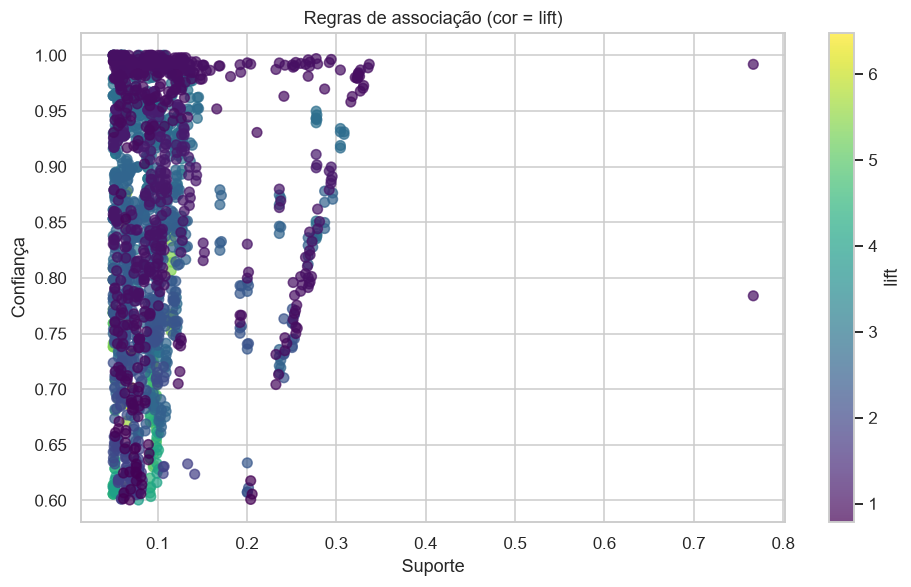

In [44]:
plt.figure(figsize=(9,5.5))
sc=plt.scatter(rules['support'],rules['confidence'],c=rules['lift'],cmap='viridis',s=40,alpha=0.7)
plt.colorbar(sc,label='lift'); plt.xlabel('Suporte'); plt.ylabel('Confiança')
plt.title('Regras de associação (cor = lift)')
plt.tight_layout(); plt.show()

## 8. Regressão linear sobre os componentes principais

Etapa **descritiva**: quanto da variação na **temperatura de equilíbrio do planeta (`pl_eqt`)** é explicada pelos componentes principais. Como os PCs são ortogonais, os coeficientes são estáveis (sem multicolinearidade).

R² (in-sample): 0.935
R² (5-fold CV): 0.933 ± 0.011

Coeficientes por componente:
PC1    191.079
PC2   -101.467
PC4    -49.209
PC5     -5.607
PC3     -0.763
dtype: float64


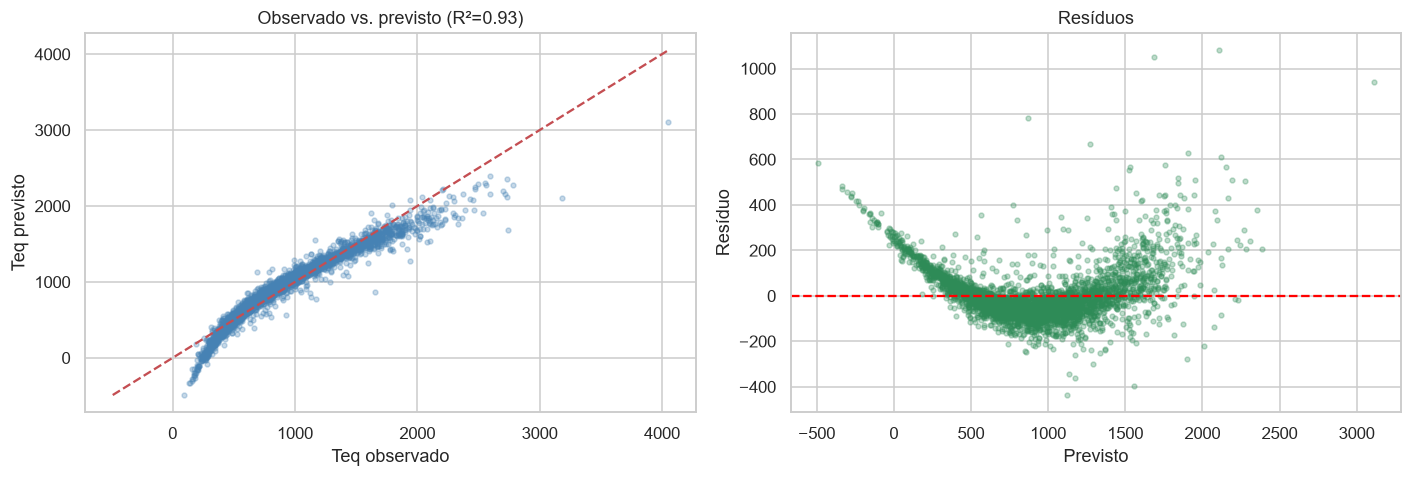

In [45]:
if 'pl_eqt' in data.columns:
    y=data['pl_eqt'].values
    reg=LinearRegression().fit(X_pca,y); r2=reg.score(X_pca,y)
    cv=cross_val_score(LinearRegression(),X_pca,y,cv=5,scoring='r2')
    print(f'R² (in-sample): {r2:.3f}')
    print(f'R² (5-fold CV): {cv.mean():.3f} ± {cv.std():.3f}')
    coefs=pd.Series(reg.coef_,index=X_pca.columns).sort_values(key=abs,ascending=False)
    print('\nCoeficientes por componente:'); print(coefs.round(3))
    pred=reg.predict(X_pca)
    fig,(a1,a2)=plt.subplots(1,2,figsize=(13,4.5))
    a1.scatter(y,pred,s=10,alpha=0.3,color='steelblue')
    lims=[min(y.min(),pred.min()),max(y.max(),pred.max())]
    a1.plot(lims,lims,'r--'); a1.set_xlabel('Teq observado'); a1.set_ylabel('Teq previsto')
    a1.set_title(f'Observado vs. previsto (R²={r2:.2f})')
    a2.scatter(pred,y-pred,s=10,alpha=0.3,color='seagreen'); a2.axhline(0,color='red',ls='--')
    a2.set_xlabel('Previsto'); a2.set_ylabel('Resíduo'); a2.set_title('Resíduos')
    plt.tight_layout(); plt.show()
else:
    print('Coluna pl_eqt indisponível — etapa de regressão pulada.')

## 9. Discussão e conclusões

**Síntese:**

1. **PCA** — poucos componentes capturam ≥85% da variância. Os primeiros eixos tendem a separar *tamanho/massa do planeta* de *configuração orbital/irradiação*, refletindo a redundância vista nas correlações.
2. **Agrupamento** — o K-Means produziu grupos interpretáveis como tipos de planeta (rochosos/super-Terras, mininetunos, gigantes gasosos). O DBSCAN agrupou o "miolo" da população e isolou como ruído os planetas raros.
3. **Anomalias** — Isolation Forest e LOF convergiram sobre os planetas mais extremos (densidades e órbitas atípicas), comportamento esperado de objetos exóticos.
4. **Regras de associação** — o Apriori revelou padrões coerentes com a física e com o viés observacional (p. ex., períodos curtos + método de trânsito; planetas grandes e quentes próximos da estrela).
5. **Regressão sobre PCs** — boa parte da variação da temperatura de equilíbrio é explicada pelos primeiros componentes, alinhada ao eixo de irradiação/distância orbital.

**Limitações:** forte viés de seleção observacional (métodos favorecem certos tipos de planeta); muitos valores ausentes em parâmetros físicos; discretização afeta o Apriori.



In [46]:
print('Resumo do pipeline')
print('='*50)
print(f'Linhas analisadas:        {len(df)}')
print(f'Features:                 {len(data.columns)}')
print(f'Componentes PCA (>=85%):  {n_comp}')
print(f'K-Means k:                {best_k} | silhouette={sil_km:.3f}')
print(f'DBSCAN clusters:          {n_clusters_db} | ruído={n_noise}')
print(f'Anomalias (IF/LOF):       {df.anom_iso.sum()}/{df.anom_lof.sum()}')
print(f'Regras (lift>1.2):        {len(rules_show)}')

Resumo do pipeline
Linhas analisadas:        3686
Features:                 12
Componentes PCA (>=85%):  5
K-Means k:                5 | silhouette=0.262
DBSCAN clusters:          3 | ruído=236
Anomalias (IF/LOF):       37/37
Regras (lift>1.2):        1268
